# Köhler Illumination Solver for TEM Condenser Stack (C1/C3/Cmini)

This notebook implements a full **symbolic + numeric** Köhler workflow for a TEM condenser stack:

- Lenses: `C1`, `C3`, `Cmini`, fixed `OPL`
- Aperture plane `A`: **after C3**
- Objective prefield lens `OPL`: fixed focal length `f_OPL = 5 mm`
- Specimen plane `Sp`: fixed at `+1 mm` after OPL

Köhler constraints are enforced as:

1. `B(S→F) = 0` where `F` is the front focal plane of OPL
2. `B(A→Sp) = 0`

The remaining free dial is used for **small finite convergence control** (`alpha`) with default target `0.5 mrad` and sweep `0.1–2.0 mrad`.


## 1) Setup, conventions, and sign policy

We use paraxial state `r = [x, theta]^T` and standard 2x2 transfer matrices:

- Drift: `P(d) = [[1, d], [0, 1]]`
- Thin lens: `L(f) = [[1, 0], [-1/f, 1]]`

Conventions used here:

- Downstream physical drift distances in the assembled chain are positive.
- For initializer formulas only, signed object distances are allowed (for example `z1 < 0`).
- When converting initializer outputs into explicit chain distances, we use positive drifts via `abs(...)`.


In [24]:
import sys
from pathlib import Path

# Ensure local src/ package imports work when notebook is run from repo root
_repo_root = Path.cwd()
_src = _repo_root / 'src'
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import math
from pprint import pprint

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    import jax
    jax.config.update("jax_enable_x64", True)
    import jax.numpy as jnp
except Exception:
    jax = None
    jnp = None

try:
    import optimistix as optx
    OPTIMISTIX_AVAILABLE = True
except Exception:
    optx = None
    OPTIMISTIX_AVAILABLE = False

if jnp is None:
    OPTIMISTIX_AVAILABLE = False

from temgym_core.transfer_matrices import calculate_z2_and_M_from_z1_and_f

sp.init_printing()
print("optimistix available:", OPTIMISTIX_AVAILABLE)


def P_num(d):
    return np.array([[1.0, float(d)], [0.0, 1.0]], dtype=float)


def L_num(f):
    return np.array([[1.0, 0.0], [-1.0 / float(f), 1.0]], dtype=float)


def compose_forward_num(ops):
    M = np.eye(2, dtype=float)
    for op in ops:
        M = np.asarray(op, dtype=float) @ M
    return M


def apply_ray_matrix(M, x, theta):
    v = np.array([x, theta], dtype=float)
    out = np.asarray(M, dtype=float) @ v
    return float(out[0]), float(out[1])


optimistix available: True


## 2) Config/defaults

These are editable defaults. They are selected to satisfy the locked assumptions:

- `f_OPL = 5e-3 m`
- `d_OPL_Sp = 1e-3 m`
- aperture after C3
- source radius `r_source = 10e-9 m`
- alpha default target `0.5e-3 rad`, sweep `0.1e-3 ... 2.0e-3 rad`
- positive focusing bounds for C1/C3/Cmini


In [25]:
cfg = {
    # Fixed optics
    "f_OPL": 5.0e-3,
    "d_OPL_Sp": 1.0e-3,

    # Editable explicit geometry drifts (all meters)
    "d_S_C1": 1.7562390861931444e-3,
    "d_C1_C3": 3.1034074475971684e-2,
    "d_C3_A": 3.786752484320379e-4,
    "d_A_Cmini": 3.994800377823778e-2,
    "d_Cmini_OPL": 2.26215732262105e-3,

    # Zoom-plane lock mode (image plane Z after C3)
    "d_C3_Z_zoom": 5.0e-3,
    "M_zoom_target": -5.0,
    "zoom_M_sweep": np.array([-8.0, -6.0, -5.0, -4.0, -2.0, 2.0, 4.0, 6.0, 8.0, 10.0], dtype=float),
    # Multistart search controls for finding multiple condenser excitations
    "multistart_n_seeds": 64,
    "multistart_seed": 13,
    "multistart_residual_tol": 1.0e-10,


    # Source size default
    "r_source": 10.0e-9,

    # Default alpha target and sweep
    "alpha_target": 0.5e-3,
    "alpha_sweep": np.linspace(0.1e-3, 2.0e-3, 17),
}

bounds = {
    "f_C1": (1.0e-3, 15.0e-3),
    "f_C3": (1.0e-3, 15.0e-3),
    "f_Cmini": (0.5e-3, 20.0e-3),
}

# Robust initial guesses
x0_step_b = np.array([1.6e-3, 8.0e-3], dtype=float)
x0_zoom = np.array([1.5e-3, 3.0e-3], dtype=float)

print("Configuration:")
pprint(cfg)
print("\nBounds:")
pprint(bounds)


Configuration:
{'M_zoom_target': -5.0,
 'alpha_sweep': array([0.0001    , 0.00021875, 0.0003375 , 0.00045625, 0.000575  ,
       0.00069375, 0.0008125 , 0.00093125, 0.00105   , 0.00116875,
       0.0012875 , 0.00140625, 0.001525  , 0.00164375, 0.0017625 ,
       0.00188125, 0.002     ]),
 'alpha_target': 0.0005,
 'd_A_Cmini': 0.03994800377823778,
 'd_C1_C3': 0.031034074475971684,
 'd_C3_A': 0.0003786752484320379,
 'd_C3_Z_zoom': 0.005,
 'd_Cmini_OPL': 0.00226215732262105,
 'd_OPL_Sp': 0.001,
 'd_S_C1': 0.0017562390861931444,
 'f_OPL': 0.005,
 'multistart_n_seeds': 64,
 'multistart_residual_tol': 1e-10,
 'multistart_seed': 13,
 'r_source': 1e-08,
 'zoom_M_sweep': array([-8., -6., -5., -4., -2.,  2.,  4.,  6.,  8., 10.])}

Bounds:
{'f_C1': (0.001, 0.015), 'f_C3': (0.001, 0.015), 'f_Cmini': (0.0005, 0.02)}


## 3) `z1/f` helper initializer (signed object distance support)

This helper uses `calculate_z2_and_M_from_z1_and_f` from `temgym_core.transfer_matrices`.

- Input `z1_signed` can be negative (object plane to lens distance convention).
- Returned `z2` and magnification `M` are from the thin-lens helper relation.
- Suggested physical drifts for chain assembly are `abs(z1_signed)` and `abs(z2)`.

This section is an initializer aid only; the final solver below uses explicit chain drifts from `cfg`.


In [26]:
def z1_f_initializer(z1_signed, focal_length):
    z2, M = calculate_z2_and_M_from_z1_and_f(z1_signed, focal_length)
    return {
        "z1_signed": float(z1_signed),
        "f": float(focal_length),
        "z2": float(z2),
        "M": float(M),
        "suggested_drift_before_lens": abs(float(z1_signed)),
        "suggested_drift_after_lens": abs(float(z2)),
    }

example_init = z1_f_initializer(z1_signed=-0.20, focal_length=2.0e-3)
print("Example z1/f initializer output:")
pprint(example_init)


Example z1/f initializer output:
{'M': -0.010101010101010102,
 'f': 0.002,
 'suggested_drift_after_lens': 0.00202020202020202,
 'suggested_drift_before_lens': 0.2,
 'z1_signed': -0.2,
 'z2': 0.00202020202020202}


## 4) Symbolic derivation (SymPy)

We build symbolic chain matrices exactly as specified:

- `M_A→Sp = P(d_A_Cmini) L(f_Cmini) P(d_Cmini_OPL) L(f_OPL) P(d_OPL_Sp)`
- `M_S→F = P(d_S_C1)L(f_C1)P(d_C1_C3)L(f_C3)P(d_C3_A)P(d_A_Cmini)L(f_Cmini)P(d_Cmini_OPL - f_OPL)`

Then extract `A, B, C, D`, simplify `B` terms, and lambdify to NumPy callables.


M_A->Sp:


⎡-d_Cmini_OPL⋅f_OPL + d_OPL_Sp⋅(d_Cmini_OPL - f_Cmini - f_OPL) + f_Cmini⋅f_OPL ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                f_Cmini⋅f_OPL                                 ↪
⎢                                                                              ↪
⎢                        d_Cmini_OPL - f_Cmini - f_OPL                         ↪
⎢                        ─────────────────────────────                         ↪
⎣                                f_Cmini⋅f_OPL                                 ↪

↪   d_A_Cmini⋅f_Cmini⋅f_OPL - d_Cmini_OPL⋅f_OPL⋅(d_A_Cmini - f_Cmini) - d_OPL_ ↪
↪   ────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪
↪                                                                              ↪
↪                                          -d_A_Cmini⋅f_Cmini - d_A_Cmini⋅f_OP ↪
↪                          


M_S->F:


⎡-d_C1_C3⋅f_C3⋅f_Cmini + f_C1⋅f_C3⋅f_Cmini + f_Cmini⋅(d_A_Cmini + d_C3_A)⋅(d_C ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                              d_C1_C3⋅f_C3 -  ↪
⎢                                                              ─────────────── ↪
⎣                                                                              ↪

↪ 1_C3 - f_C1 - f_C3) - (d_Cmini_OPL - f_OPL)⋅(-d_C1_C3⋅f_C3 + f_C1⋅f_C3 + f_C ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                   f_C1⋅f_C3⋅f_Cmini                          ↪
↪                                                                              ↪
↪ f_C1⋅f_C3 - f_C3⋅f_Cmini + f_Cmini⋅(d_C1_C3 - f_C1) + (d_A_Cmini + d_C3_A)⋅( ↪
↪ ─────────────────────────


M_S->Z:


⎡-d_C1_C3⋅f_C3 + d_C3_Z⋅(d_C1_C3 - f_C1 - f_C3) + f_C1⋅f_C3  -d_C1_C3⋅f_C3⋅(d_ ↪
⎢──────────────────────────────────────────────────────────  ───────────────── ↪
⎢                        f_C1⋅f_C3                                             ↪
⎢                                                                              ↪
⎢                  d_C1_C3 - f_C1 - f_C3                                       ↪
⎢                  ─────────────────────                                       ↪
⎣                        f_C1⋅f_C3                                             ↪

↪ S_C1 - f_C1) - d_C3_Z⋅(-d_C1_C3⋅(d_S_C1 - f_C1) + d_S_C1⋅f_C1 + d_S_C1⋅f_C3  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                         f_C1⋅f_C3                            ↪
↪                                                                              ↪
↪              d_C1_C3⋅(d_S_C1 - f_C1) - d_S_C1⋅f_C1 - d_S_C1⋅f_C3 + f_C1⋅f_C3 ↪
↪              ────────────


Simplified symbolic B terms:


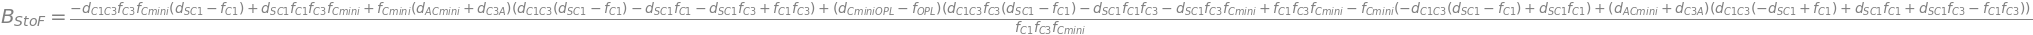

In [27]:
# Symbols
sym_d_S_C1, sym_d_C1_C3, sym_d_C3_A, sym_d_A_Cmini, sym_d_Cmini_OPL, sym_d_OPL_Sp, sym_d_C3_Z = sp.symbols(
    "d_S_C1 d_C1_C3 d_C3_A d_A_Cmini d_Cmini_OPL d_OPL_Sp d_C3_Z", positive=True, finite=True
)
sym_f_C1, sym_f_C3, sym_f_Cmini, sym_f_OPL = sp.symbols(
    "f_C1 f_C3 f_Cmini f_OPL", positive=True, finite=True
)


def P_sym(d):
    return sp.Matrix([[1, d], [0, 1]])


def L_sym(f):
    return sp.Matrix([[1, 0], [-1 / f, 1]])


def compose_forward_sym(ops):
    M = sp.eye(2)
    for op in ops:
        M = op @ M
    return sp.simplify(M)


M_A_to_Sp_sym = compose_forward_sym([
    P_sym(sym_d_A_Cmini),
    L_sym(sym_f_Cmini),
    P_sym(sym_d_Cmini_OPL),
    L_sym(sym_f_OPL),
    P_sym(sym_d_OPL_Sp),
])

M_S_to_F_sym = compose_forward_sym([
    P_sym(sym_d_S_C1),
    L_sym(sym_f_C1),
    P_sym(sym_d_C1_C3),
    L_sym(sym_f_C3),
    P_sym(sym_d_C3_A),
    P_sym(sym_d_A_Cmini),
    L_sym(sym_f_Cmini),
    P_sym(sym_d_Cmini_OPL - sym_f_OPL),
])

M_S_to_Z_sym = compose_forward_sym([
    P_sym(sym_d_S_C1),
    L_sym(sym_f_C1),
    P_sym(sym_d_C1_C3),
    L_sym(sym_f_C3),
    P_sym(sym_d_C3_Z),
])

A_ASp_sym, B_ASp_sym = sp.simplify(M_A_to_Sp_sym[0, 0]), sp.simplify(M_A_to_Sp_sym[0, 1])
C_ASp_sym, D_ASp_sym = sp.simplify(M_A_to_Sp_sym[1, 0]), sp.simplify(M_A_to_Sp_sym[1, 1])

A_SF_sym, B_SF_sym = sp.simplify(M_S_to_F_sym[0, 0]), sp.simplify(M_S_to_F_sym[0, 1])
C_SF_sym, D_SF_sym = sp.simplify(M_S_to_F_sym[1, 0]), sp.simplify(M_S_to_F_sym[1, 1])

A_SZ_sym, B_SZ_sym = sp.simplify(M_S_to_Z_sym[0, 0]), sp.simplify(M_S_to_Z_sym[0, 1])
C_SZ_sym, D_SZ_sym = sp.simplify(M_S_to_Z_sym[1, 0]), sp.simplify(M_S_to_Z_sym[1, 1])

print("M_A->Sp:")
display(M_A_to_Sp_sym)
print("\nM_S->F:")
display(M_S_to_F_sym)
print("\nM_S->Z:")
display(M_S_to_Z_sym)

print("\nSimplified symbolic B terms:")
display(sp.Eq(sp.Symbol("B_A_to_Sp"), B_ASp_sym))
display(sp.Eq(sp.Symbol("B_S_to_F"), B_SF_sym))
display(sp.Eq(sp.Symbol("B_S_to_Z"), B_SZ_sym))

display(sp.Eq(sp.Symbol("A_S_to_Z"), A_SZ_sym))


In [28]:
# Lambdified numeric functions (NumPy backend)
B_ASp_num = sp.lambdify(
    (sym_d_A_Cmini, sym_d_Cmini_OPL, sym_f_Cmini, sym_f_OPL, sym_d_OPL_Sp),
    B_ASp_sym,
    "numpy",
)

A_ASp_num = sp.lambdify(
    (sym_d_A_Cmini, sym_d_Cmini_OPL, sym_f_Cmini, sym_f_OPL, sym_d_OPL_Sp),
    A_ASp_sym,
    "numpy",
)

B_SF_num = sp.lambdify(
    (
        sym_d_S_C1,
        sym_d_C1_C3,
        sym_d_C3_A,
        sym_d_A_Cmini,
        sym_d_Cmini_OPL,
        sym_f_C1,
        sym_f_C3,
        sym_f_Cmini,
        sym_f_OPL,
    ),
    B_SF_sym,
    "numpy",
)

A_SF_num = sp.lambdify(
    (
        sym_d_S_C1,
        sym_d_C1_C3,
        sym_d_C3_A,
        sym_d_A_Cmini,
        sym_d_Cmini_OPL,
        sym_f_C1,
        sym_f_C3,
        sym_f_Cmini,
        sym_f_OPL,
    ),
    A_SF_sym,
    "numpy",
)

B_SZ_num = sp.lambdify(
    (
        sym_d_S_C1,
        sym_d_C1_C3,
        sym_d_C3_Z,
        sym_f_C1,
        sym_f_C3,
    ),
    B_SZ_sym,
    "numpy",
)

A_SZ_num = sp.lambdify(
    (
        sym_d_S_C1,
        sym_d_C1_C3,
        sym_d_C3_Z,
        sym_f_C1,
        sym_f_C3,
    ),
    A_SZ_sym,
    "numpy",
)

print("Lambdified functions ready.")


Lambdified functions ready.


## 5) Numeric solver

### Step A
Solve `B_A->Sp(f_Cmini)=0` within positive bounds.

Method:
1. logspace bracket scan
2. if `optimistix` is available and sign change exists: bisection root-find
3. otherwise: bracketed secant/bisection hybrid
4. if no sign change: minimize absolute residual candidate + local refine

### Step B
With solved `f_Cmini*`, solve for `(f_C1, f_C3)`:

- `r1 = B_S->F(f_C1, f_C3, f_Cmini*)`
- `r2 = alpha(f_C1, f_C3) - alpha_target`

with
`r_F = |A_S->F| * r_source`, `alpha = r_F / f_OPL`.

Method:
- if `optimistix` available: bounded-variable Levenberg-Marquardt root-find
- fallback: damped Newton + finite-difference Jacobian + line search
- fallback seed: coarse 2D grid search

### Zoom lock mode
Additional mode locks image plane at `Z` after `C3`:
- `B_S->Z = 0`
- `A_S->Z = M_zoom_target`

Solved with the same `optimistix`/fallback strategy.


In [29]:
def eval_B_ASp(f_cmini, cfg_local):
    return float(
        B_ASp_num(
            cfg_local["d_A_Cmini"],
            cfg_local["d_Cmini_OPL"],
            f_cmini,
            cfg_local["f_OPL"],
            cfg_local["d_OPL_Sp"],
        )
    )


def eval_A_ASp(f_cmini, cfg_local):
    return float(
        A_ASp_num(
            cfg_local["d_A_Cmini"],
            cfg_local["d_Cmini_OPL"],
            f_cmini,
            cfg_local["f_OPL"],
            cfg_local["d_OPL_Sp"],
        )
    )


def eval_B_SF(f_c1, f_c3, f_cmini, cfg_local):
    return float(
        B_SF_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C3"],
            cfg_local["d_C3_A"],
            cfg_local["d_A_Cmini"],
            cfg_local["d_Cmini_OPL"],
            f_c1,
            f_c3,
            f_cmini,
            cfg_local["f_OPL"],
        )
    )


def eval_A_SF(f_c1, f_c3, f_cmini, cfg_local):
    return float(
        A_SF_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C3"],
            cfg_local["d_C3_A"],
            cfg_local["d_A_Cmini"],
            cfg_local["d_Cmini_OPL"],
            f_c1,
            f_c3,
            f_cmini,
            cfg_local["f_OPL"],
        )
    )


def eval_B_SZ(f_c1, f_c3, cfg_local):
    return float(
        B_SZ_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C3"],
            cfg_local["d_C3_Z_zoom"],
            f_c1,
            f_c3,
        )
    )


def eval_A_SZ(f_c1, f_c3, cfg_local):
    return float(
        A_SZ_num(
            cfg_local["d_S_C1"],
            cfg_local["d_C1_C3"],
            cfg_local["d_C3_Z_zoom"],
            f_c1,
            f_c3,
        )
    )


def eval_alpha(f_c1, f_c3, f_cmini, cfg_local):
    r_F = abs(eval_A_SF(f_c1, f_c3, f_cmini, cfg_local)) * cfg_local["r_source"]
    return r_F / cfg_local["f_OPL"]


# --- JAX-compatible matrix evaluators for optimistix ---
def P_jax(d):
    return jnp.array([[1.0, d], [0.0, 1.0]], dtype=jnp.float64)


def L_jax(f):
    return jnp.array([[1.0, 0.0], [-1.0 / f, 1.0]], dtype=jnp.float64)


def compose_forward_jax(ops):
    M = jnp.eye(2, dtype=jnp.float64)
    for op in ops:
        M = op @ M
    return M


def eval_B_ASp_jax(f_cmini, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_A_Cmini"]),
        L_jax(f_cmini),
        P_jax(cfg_local["d_Cmini_OPL"]),
        L_jax(cfg_local["f_OPL"]),
        P_jax(cfg_local["d_OPL_Sp"]),
    ])
    return M[0, 1]


def eval_A_ASp_jax(f_cmini, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_A_Cmini"]),
        L_jax(f_cmini),
        P_jax(cfg_local["d_Cmini_OPL"]),
        L_jax(cfg_local["f_OPL"]),
        P_jax(cfg_local["d_OPL_Sp"]),
    ])
    return M[0, 0]


def eval_B_SF_jax(f_c1, f_c3, f_cmini, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_S_C1"]),
        L_jax(f_c1),
        P_jax(cfg_local["d_C1_C3"]),
        L_jax(f_c3),
        P_jax(cfg_local["d_C3_A"]),
        P_jax(cfg_local["d_A_Cmini"]),
        L_jax(f_cmini),
        P_jax(cfg_local["d_Cmini_OPL"] - cfg_local["f_OPL"]),
    ])
    return M[0, 1]


def eval_A_SF_jax(f_c1, f_c3, f_cmini, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_S_C1"]),
        L_jax(f_c1),
        P_jax(cfg_local["d_C1_C3"]),
        L_jax(f_c3),
        P_jax(cfg_local["d_C3_A"]),
        P_jax(cfg_local["d_A_Cmini"]),
        L_jax(f_cmini),
        P_jax(cfg_local["d_Cmini_OPL"] - cfg_local["f_OPL"]),
    ])
    return M[0, 0]


def eval_alpha_jax(f_c1, f_c3, f_cmini, cfg_local):
    return jnp.abs(eval_A_SF_jax(f_c1, f_c3, f_cmini, cfg_local)) * cfg_local["r_source"] / cfg_local["f_OPL"]


def eval_B_SZ_jax(f_c1, f_c3, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_S_C1"]),
        L_jax(f_c1),
        P_jax(cfg_local["d_C1_C3"]),
        L_jax(f_c3),
        P_jax(cfg_local["d_C3_Z_zoom"]),
    ])
    return M[0, 1]


def eval_A_SZ_jax(f_c1, f_c3, cfg_local):
    M = compose_forward_jax([
        P_jax(cfg_local["d_S_C1"]),
        L_jax(f_c1),
        P_jax(cfg_local["d_C1_C3"]),
        L_jax(f_c3),
        P_jax(cfg_local["d_C3_Z_zoom"]),
    ])
    return M[0, 0]


def bounded_logistic_to_physical_np(u, bounds_arr):
    bounds_arr = np.asarray(bounds_arr, dtype=float)
    lo = bounds_arr[:, 0]
    hi = bounds_arr[:, 1]
    u_arr = np.asarray(u, dtype=float)
    u_clip = np.clip(u_arr, -60.0, 60.0)
    s = 1.0 / (1.0 + np.exp(-u_clip))
    return lo + (hi - lo) * s


def bounded_logit_from_physical_np(x, bounds_arr):
    bounds_arr = np.asarray(bounds_arr, dtype=float)
    lo = bounds_arr[:, 0]
    hi = bounds_arr[:, 1]
    s = np.clip((np.asarray(x, dtype=float) - lo) / (hi - lo), 1e-9, 1.0 - 1e-9)
    return np.log(s) - np.log1p(-s)


def bounded_logistic_to_physical_jax(u, bounds_arr):
    bounds_arr_j = jnp.asarray(bounds_arr, dtype=jnp.float64)
    lo = bounds_arr_j[:, 0]
    hi = bounds_arr_j[:, 1]
    return lo + (hi - lo) * jax.nn.sigmoid(u)


def bracket_scan_log(func, fmin, fmax, n=400):
    xs = np.geomspace(fmin, fmax, int(n))
    ys = np.array([func(x) for x in xs], dtype=float)
    bracket = None
    for i in range(len(xs) - 1):
        y0, y1 = ys[i], ys[i + 1]
        if not np.isfinite(y0) or not np.isfinite(y1):
            continue
        if y0 == 0.0:
            bracket = (xs[i], xs[i])
            break
        if np.sign(y0) != np.sign(y1):
            bracket = (xs[i], xs[i + 1])
            break
    return xs, ys, bracket


def root_hybrid_bracketed(func, a, b, tol=1e-14, max_iter=120):
    fa = float(func(a))
    fb = float(func(b))
    if not np.isfinite(fa) or not np.isfinite(fb):
        return {"success": False, "status": "nonfinite_endpoints", "root": np.nan, "residual": np.inf, "iterations": 0}

    if a == b:
        return {"success": abs(fa) <= tol, "status": "exact_grid_point", "root": float(a), "residual": abs(fa), "iterations": 0}

    if np.sign(fa) == np.sign(fb):
        return {"success": False, "status": "invalid_bracket", "root": np.nan, "residual": np.inf, "iterations": 0}

    x = 0.5 * (a + b)
    fx = float(func(x))

    for it in range(1, max_iter + 1):
        denom = (fb - fa)
        if denom != 0.0:
            x_sec = b - fb * (b - a) / denom
        else:
            x_sec = 0.5 * (a + b)

        if not (min(a, b) < x_sec < max(a, b)) or not np.isfinite(x_sec):
            x_new = 0.5 * (a + b)
        else:
            x_new = x_sec

        f_new = float(func(x_new))
        if not np.isfinite(f_new):
            x_new = 0.5 * (a + b)
            f_new = float(func(x_new))

        if abs(f_new) < tol or abs(b - a) < tol:
            return {
                "success": True,
                "status": "converged",
                "root": float(x_new),
                "residual": abs(f_new),
                "iterations": it,
            }

        if np.sign(fa) * np.sign(f_new) <= 0:
            b, fb = x_new, f_new
        else:
            a, fa = x_new, f_new

        x, fx = x_new, f_new

    return {
        "success": abs(fx) < 1e-10,
        "status": "max_iter",
        "root": float(x),
        "residual": abs(fx),
        "iterations": max_iter,
    }


def refine_min_abs_scalar(func, x0, fmin, fmax, tol=1e-14, max_iter=80):
    x = float(np.clip(x0, fmin, fmax))
    fx = float(func(x))
    if not np.isfinite(fx):
        return {"success": False, "status": "nonfinite_start", "root": np.nan, "residual": np.inf, "iterations": 0}

    for it in range(1, max_iter + 1):
        if abs(fx) < tol:
            return {"success": True, "status": "converged", "root": x, "residual": abs(fx), "iterations": it}

        h = max(1e-12, 1e-6 * max(abs(x), 1e-6))
        x_p = float(np.clip(x + h, fmin, fmax))
        x_m = float(np.clip(x - h, fmin, fmax))

        f_p = float(func(x_p))
        f_m = float(func(x_m))
        if not (np.isfinite(f_p) and np.isfinite(f_m)):
            return {"success": False, "status": "nonfinite_fd", "root": x, "residual": abs(fx), "iterations": it}

        denom = (x_p - x_m)
        if abs(denom) < 1e-18:
            return {"success": False, "status": "tiny_fd_span", "root": x, "residual": abs(fx), "iterations": it}

        dfx = (f_p - f_m) / denom
        if dfx == 0.0 or not np.isfinite(dfx):
            return {"success": False, "status": "zero_fd_derivative", "root": x, "residual": abs(fx), "iterations": it}

        step = -fx / dfx
        lam = 1.0
        improved = False
        for _ in range(20):
            x_new = float(np.clip(x + lam * step, fmin, fmax))
            f_new = float(func(x_new))
            if np.isfinite(f_new) and abs(f_new) < abs(fx):
                x, fx = x_new, f_new
                improved = True
                break
            lam *= 0.5

        if not improved:
            return {"success": False, "status": "line_search_fail", "root": x, "residual": abs(fx), "iterations": it}

    return {"success": abs(fx) < 1e-10, "status": "max_iter", "root": x, "residual": abs(fx), "iterations": max_iter}


def solve_scalar_root_optimistix_bisection(fn_jax, a, b, args, tol=1e-14, max_steps=220):
    if not OPTIMISTIX_AVAILABLE:
        return {
            "success": False,
            "status": "optimistix_unavailable",
            "root": np.nan,
            "residual": np.inf,
            "iterations": 0,
        }

    try:
        solver = optx.Bisection(rtol=tol, atol=tol)
        y0 = jnp.asarray(0.5 * (a + b), dtype=jnp.float64)
        options = {
            "lower": jnp.asarray(a, dtype=jnp.float64),
            "upper": jnp.asarray(b, dtype=jnp.float64),
        }
        sol = optx.root_find(
            fn_jax,
            solver,
            y0=y0,
            args=args,
            options=options,
            max_steps=max_steps,
            throw=False,
        )
        root = float(np.asarray(sol.value, dtype=float))
        residual = float(abs(np.asarray(fn_jax(jnp.asarray(root, dtype=jnp.float64), args), dtype=float)))
        success = bool(sol.result == optx.RESULTS.successful and np.isfinite(root))
        return {
            "success": success,
            "status": str(sol.result),
            "root": root,
            "residual": residual,
            "iterations": int(np.asarray(sol.stats.get("num_steps", 0))),
        }
    except Exception as exc:
        return {
            "success": False,
            "status": f"optimistix_exception:{type(exc).__name__}",
            "root": np.nan,
            "residual": np.inf,
            "iterations": 0,
        }


def solve_2eq_optimistix_lm(residual_u_jax, args, bounds_arr, x0, tol=1e-12, max_steps=220):
    if not OPTIMISTIX_AVAILABLE:
        return {
            "success": False,
            "status": "optimistix_unavailable",
            "u": None,
            "x": np.asarray(x0, dtype=float),
            "iterations": 0,
            "result": None,
        }

    bounds_arr = np.asarray(bounds_arr, dtype=float)
    x0_clipped = np.clip(np.asarray(x0, dtype=float), bounds_arr[:, 0], bounds_arr[:, 1])
    u0 = bounded_logit_from_physical_np(x0_clipped, bounds_arr)

    try:
        solver = optx.LevenbergMarquardt(rtol=tol, atol=tol)
        sol = optx.root_find(
            residual_u_jax,
            solver,
            y0=jnp.asarray(u0, dtype=jnp.float64),
            args=args,
            options={"jac": "fwd"},
            max_steps=max_steps,
            throw=False,
        )

        u_star = np.asarray(sol.value, dtype=float)
        x_star = bounded_logistic_to_physical_np(u_star, bounds_arr)
        return {
            "success": bool(sol.result == optx.RESULTS.successful),
            "status": str(sol.result),
            "u": u_star,
            "x": x_star,
            "iterations": int(np.asarray(sol.stats.get("num_steps", 0))),
            "result": sol,
        }
    except Exception as exc:
        return {
            "success": False,
            "status": f"optimistix_exception:{type(exc).__name__}",
            "u": None,
            "x": x0_clipped,
            "iterations": 0,
            "result": None,
        }


def solve_step_a(cfg_local, bounds_local):
    fmin, fmax = bounds_local["f_Cmini"]
    func = lambda f: eval_B_ASp(f, cfg_local)
    xs, ys, bracket = bracket_scan_log(func, fmin, fmax, n=600)

    if bracket is not None:
        a, b = float(bracket[0]), float(bracket[1])
        if OPTIMISTIX_AVAILABLE:
            out = solve_scalar_root_optimistix_bisection(
                lambda y, c: eval_B_ASp_jax(y, c),
                a,
                b,
                args=cfg_local,
                tol=1e-14,
                max_steps=260,
            )
            out["method"] = "optimistix_bisection"
            out["scan_x"] = xs
            out["scan_y"] = ys
            if out["success"]:
                return out

        out = root_hybrid_bracketed(func, a, b, tol=1e-15, max_iter=140)
        out["method"] = "bracketed_hybrid"
        out["scan_x"] = xs
        out["scan_y"] = ys
        return out

    idx = int(np.argmin(np.abs(ys)))
    x0 = float(xs[idx])
    out = refine_min_abs_scalar(func, x0, fmin, fmax, tol=1e-15, max_iter=120)
    out["method"] = "min_abs_refine"
    out["scan_x"] = xs
    out["scan_y"] = ys
    return out


def residual_step_b(x, alpha_target, f_cmini, cfg_local):
    f_c1, f_c3 = float(x[0]), float(x[1])
    r1 = eval_B_SF(f_c1, f_c3, f_cmini, cfg_local)
    alpha = eval_alpha(f_c1, f_c3, f_cmini, cfg_local)
    r2 = alpha - float(alpha_target)
    return np.array([r1, r2], dtype=float), alpha


def residual_step_b_u_jax(u, args):
    alpha_target, f_cmini, cfg_local, bounds_arr = args
    f_pair = bounded_logistic_to_physical_jax(u, bounds_arr)
    f_c1, f_c3 = f_pair[0], f_pair[1]
    r1 = eval_B_SF_jax(f_c1, f_c3, f_cmini, cfg_local)
    r2 = eval_alpha_jax(f_c1, f_c3, f_cmini, cfg_local) - alpha_target
    return jnp.array([r1, r2], dtype=jnp.float64)


def solve_step_b_optimistix(alpha_target, f_cmini, cfg_local, bounds_local, x0, tol=1e-12, max_steps=220):
    bounds_arr = np.array([bounds_local["f_C1"], bounds_local["f_C3"]], dtype=float)
    args = (float(alpha_target), float(f_cmini), cfg_local, bounds_arr)

    raw = solve_2eq_optimistix_lm(
        residual_step_b_u_jax,
        args=args,
        bounds_arr=bounds_arr,
        x0=x0,
        tol=tol,
        max_steps=max_steps,
    )

    x = np.clip(np.asarray(raw["x"], dtype=float), bounds_arr[:, 0], bounds_arr[:, 1])
    r, alpha_now = residual_step_b(x, alpha_target, f_cmini, cfg_local)

    return {
        "success": bool(raw["success"] and np.linalg.norm(r) < 1e-10),
        "status": raw["status"],
        "x": x,
        "residual": r,
        "residual_norm": float(np.linalg.norm(r)),
        "alpha": float(alpha_now),
        "iterations": int(raw["iterations"]),
        "history": [],
        "method": "optimistix_lm",
    }


def fd_jacobian_step_b(x, alpha_target, f_cmini, cfg_local, bounds_arr):
    x = np.asarray(x, dtype=float)
    J = np.zeros((2, 2), dtype=float)
    for j in range(2):
        h = max(1e-9, 1e-6 * max(abs(x[j]), 1e-6))
        x_p = x.copy()
        x_m = x.copy()
        x_p[j] = np.clip(x_p[j] + h, bounds_arr[j, 0], bounds_arr[j, 1])
        x_m[j] = np.clip(x_m[j] - h, bounds_arr[j, 0], bounds_arr[j, 1])

        r_p, _ = residual_step_b(x_p, alpha_target, f_cmini, cfg_local)
        r_m, _ = residual_step_b(x_m, alpha_target, f_cmini, cfg_local)

        denom = x_p[j] - x_m[j]
        if abs(denom) < 1e-18:
            denom = 1e-18
        J[:, j] = (r_p - r_m) / denom
    return J


def damped_newton_step_b(alpha_target, f_cmini, cfg_local, bounds_local, x0, tol=1e-12, max_iter=80):
    bounds_arr = np.array([bounds_local["f_C1"], bounds_local["f_C3"]], dtype=float)
    x = np.clip(np.asarray(x0, dtype=float), bounds_arr[:, 0], bounds_arr[:, 1])

    hist = []

    for it in range(1, max_iter + 1):
        r, alpha_now = residual_step_b(x, alpha_target, f_cmini, cfg_local)
        norm_r = float(np.linalg.norm(r))
        hist.append((it, x.copy(), r.copy(), norm_r, alpha_now))

        if norm_r < tol:
            return {
                "success": True,
                "status": "converged",
                "x": x,
                "residual": r,
                "residual_norm": norm_r,
                "alpha": alpha_now,
                "iterations": it,
                "history": hist,
            }

        J = fd_jacobian_step_b(x, alpha_target, f_cmini, cfg_local, bounds_arr)
        try:
            step = np.linalg.solve(J, -r)
        except np.linalg.LinAlgError:
            step = -np.linalg.pinv(J) @ r

        improved = False
        lam = 1.0
        for _ in range(25):
            x_try = np.clip(x + lam * step, bounds_arr[:, 0], bounds_arr[:, 1])
            r_try, _ = residual_step_b(x_try, alpha_target, f_cmini, cfg_local)
            norm_try = float(np.linalg.norm(r_try))
            if np.isfinite(norm_try) and norm_try < norm_r:
                x = x_try
                improved = True
                break
            lam *= 0.5

        if not improved:
            return {
                "success": False,
                "status": "line_search_fail",
                "x": x,
                "residual": r,
                "residual_norm": norm_r,
                "alpha": alpha_now,
                "iterations": it,
                "history": hist,
            }

    r, alpha_now = residual_step_b(x, alpha_target, f_cmini, cfg_local)
    norm_r = float(np.linalg.norm(r))
    return {
        "success": norm_r < 1e-9,
        "status": "max_iter",
        "x": x,
        "residual": r,
        "residual_norm": norm_r,
        "alpha": alpha_now,
        "iterations": max_iter,
        "history": hist,
    }


def coarse_grid_seed_step_b(alpha_target, f_cmini, cfg_local, bounds_local, n_f1=60, n_f3=60):
    f1s = np.geomspace(bounds_local["f_C1"][0], bounds_local["f_C1"][1], int(n_f1))
    f3s = np.geomspace(bounds_local["f_C3"][0], bounds_local["f_C3"][1], int(n_f3))

    best_norm = np.inf
    best_x = None

    for f1 in f1s:
        for f3 in f3s:
            r, _ = residual_step_b(np.array([f1, f3]), alpha_target, f_cmini, cfg_local)
            nrm = float(np.linalg.norm(r))
            if nrm < best_norm:
                best_norm = nrm
                best_x = np.array([f1, f3], dtype=float)

    return best_x, best_norm


def solve_step_b(alpha_target, f_cmini, cfg_local, bounds_local, x0):
    if OPTIMISTIX_AVAILABLE:
        out_optx = solve_step_b_optimistix(alpha_target, f_cmini, cfg_local, bounds_local, x0=x0)
        if out_optx["success"]:
            return out_optx

    out = damped_newton_step_b(alpha_target, f_cmini, cfg_local, bounds_local, x0=x0)
    if out["success"]:
        out["method"] = "damped_newton"
        return out

    seed, seed_norm = coarse_grid_seed_step_b(alpha_target, f_cmini, cfg_local, bounds_local, n_f1=70, n_f3=70)
    out2 = damped_newton_step_b(alpha_target, f_cmini, cfg_local, bounds_local, x0=seed)
    out2["method"] = "coarse_seed + damped_newton"
    out2["coarse_seed"] = seed
    out2["coarse_seed_norm"] = seed_norm
    return out2


def build_matrices_for_solution(f_c1, f_c3, f_cmini, cfg_local):
    M_A_to_Sp = compose_forward_num([
        P_num(cfg_local["d_A_Cmini"]),
        L_num(f_cmini),
        P_num(cfg_local["d_Cmini_OPL"]),
        L_num(cfg_local["f_OPL"]),
        P_num(cfg_local["d_OPL_Sp"]),
    ])

    M_S_to_F = compose_forward_num([
        P_num(cfg_local["d_S_C1"]),
        L_num(f_c1),
        P_num(cfg_local["d_C1_C3"]),
        L_num(f_c3),
        P_num(cfg_local["d_C3_A"]),
        P_num(cfg_local["d_A_Cmini"]),
        L_num(f_cmini),
        P_num(cfg_local["d_Cmini_OPL"] - cfg_local["f_OPL"]),
    ])

    return M_A_to_Sp, M_S_to_F


def solve_kohler_single_alpha(alpha_target, cfg_local, bounds_local, x0=None):
    if x0 is None:
        x0 = np.array([
            np.sqrt(bounds_local["f_C1"][0] * bounds_local["f_C1"][1]),
            np.sqrt(bounds_local["f_C3"][0] * bounds_local["f_C3"][1]),
        ], dtype=float)

    step_a = solve_step_a(cfg_local, bounds_local)
    f_cmini = float(step_a["root"])

    step_b = solve_step_b(alpha_target, f_cmini, cfg_local, bounds_local, x0=x0)

    f_c1, f_c3 = float(step_b["x"][0]), float(step_b["x"][1])
    alpha_ach = float(step_b["alpha"])
    B_sf = float(step_b["residual"][0])
    alpha_err = float(step_b["residual"][1])
    A_sf = float(eval_A_SF(f_c1, f_c3, f_cmini, cfg_local))
    B_asp = float(eval_B_ASp(f_cmini, cfg_local))
    A_asp = float(eval_A_ASp(f_cmini, cfg_local))

    result = {
        "success": bool(step_a["success"] and step_b["success"]),
        "status": f"stepA:{step_a['status']} | stepB:{step_b['status']}",
        "alpha_target": float(alpha_target),
        "alpha": alpha_ach,
        "A_SF": A_sf,
        "B_SF": B_sf,
        "B_ASp": B_asp,
        "A_ASp": A_asp,
        "f_C1": f_c1,
        "f_C3": f_c3,
        "f_Cmini": f_cmini,
        "residual_B_SF": B_sf,
        "residual_alpha": alpha_err,
        "iterations_step_a": int(step_a["iterations"]),
        "iterations_step_b": int(step_b["iterations"]),
        "stepA": step_a,
        "stepB": step_b,
    }

    return result


def solve_alpha_sweep(alpha_targets, cfg_local, bounds_local, x0_init):
    results = []
    x0 = np.asarray(x0_init, dtype=float).copy()
    for a_tgt in np.asarray(alpha_targets, dtype=float):
        out = solve_kohler_single_alpha(a_tgt, cfg_local, bounds_local, x0=x0)
        results.append(out)
        x0 = np.array([out["f_C1"], out["f_C3"]], dtype=float)
    return results


# --- Zoom plane-lock solver: B(S->Z)=0 and A(S->Z)=M_target ---
def residual_zoom_pair(x, M_target, cfg_local):
    f_c1, f_c3 = float(x[0]), float(x[1])
    r1 = eval_B_SZ(f_c1, f_c3, cfg_local)
    r2 = eval_A_SZ(f_c1, f_c3, cfg_local) - float(M_target)
    return np.array([r1, r2], dtype=float)


def residual_zoom_pair_u_jax(u, args):
    M_target, cfg_local, bounds_arr = args
    f_pair = bounded_logistic_to_physical_jax(u, bounds_arr)
    f_c1, f_c3 = f_pair[0], f_pair[1]
    r1 = eval_B_SZ_jax(f_c1, f_c3, cfg_local)
    r2 = eval_A_SZ_jax(f_c1, f_c3, cfg_local) - M_target
    return jnp.array([r1, r2], dtype=jnp.float64)


def fd_jacobian_zoom_pair(x, M_target, cfg_local, bounds_arr):
    x = np.asarray(x, dtype=float)
    J = np.zeros((2, 2), dtype=float)
    for j in range(2):
        h = max(1e-9, 1e-6 * max(abs(x[j]), 1e-6))
        x_p = x.copy()
        x_m = x.copy()
        x_p[j] = np.clip(x_p[j] + h, bounds_arr[j, 0], bounds_arr[j, 1])
        x_m[j] = np.clip(x_m[j] - h, bounds_arr[j, 0], bounds_arr[j, 1])

        r_p = residual_zoom_pair(x_p, M_target, cfg_local)
        r_m = residual_zoom_pair(x_m, M_target, cfg_local)

        denom = x_p[j] - x_m[j]
        if abs(denom) < 1e-18:
            denom = 1e-18
        J[:, j] = (r_p - r_m) / denom
    return J


def damped_newton_zoom_pair(M_target, cfg_local, bounds_local, x0, tol=1e-12, max_iter=80):
    bounds_arr = np.array([bounds_local["f_C1"], bounds_local["f_C3"]], dtype=float)
    x = np.clip(np.asarray(x0, dtype=float), bounds_arr[:, 0], bounds_arr[:, 1])

    for it in range(1, max_iter + 1):
        r = residual_zoom_pair(x, M_target, cfg_local)
        norm_r = float(np.linalg.norm(r))
        if norm_r < tol:
            return {
                "success": True,
                "status": "converged",
                "x": x,
                "residual": r,
                "residual_norm": norm_r,
                "iterations": it,
            }

        J = fd_jacobian_zoom_pair(x, M_target, cfg_local, bounds_arr)
        try:
            step = np.linalg.solve(J, -r)
        except np.linalg.LinAlgError:
            step = -np.linalg.pinv(J) @ r

        improved = False
        lam = 1.0
        for _ in range(25):
            x_try = np.clip(x + lam * step, bounds_arr[:, 0], bounds_arr[:, 1])
            r_try = residual_zoom_pair(x_try, M_target, cfg_local)
            norm_try = float(np.linalg.norm(r_try))
            if np.isfinite(norm_try) and norm_try < norm_r:
                x = x_try
                improved = True
                break
            lam *= 0.5

        if not improved:
            return {
                "success": False,
                "status": "line_search_fail",
                "x": x,
                "residual": r,
                "residual_norm": norm_r,
                "iterations": it,
            }

    r = residual_zoom_pair(x, M_target, cfg_local)
    norm_r = float(np.linalg.norm(r))
    return {
        "success": norm_r < 1e-9,
        "status": "max_iter",
        "x": x,
        "residual": r,
        "residual_norm": norm_r,
        "iterations": max_iter,
    }


def coarse_grid_seed_zoom_pair(M_target, cfg_local, bounds_local, n_f1=70, n_f3=70):
    f1s = np.geomspace(bounds_local["f_C1"][0], bounds_local["f_C1"][1], int(n_f1))
    f3s = np.geomspace(bounds_local["f_C3"][0], bounds_local["f_C3"][1], int(n_f3))

    best_norm = np.inf
    best_x = None

    for f1 in f1s:
        for f3 in f3s:
            r = residual_zoom_pair(np.array([f1, f3], dtype=float), M_target, cfg_local)
            nrm = float(np.linalg.norm(r))
            if nrm < best_norm:
                best_norm = nrm
                best_x = np.array([f1, f3], dtype=float)

    return best_x, best_norm


def solve_zoom_pair_optimistix(M_target, cfg_local, bounds_local, x0, tol=1e-12, max_steps=220):
    bounds_arr = np.array([bounds_local["f_C1"], bounds_local["f_C3"]], dtype=float)
    args = (float(M_target), cfg_local, bounds_arr)

    raw = solve_2eq_optimistix_lm(
        residual_zoom_pair_u_jax,
        args=args,
        bounds_arr=bounds_arr,
        x0=x0,
        tol=tol,
        max_steps=max_steps,
    )

    x = np.clip(np.asarray(raw["x"], dtype=float), bounds_arr[:, 0], bounds_arr[:, 1])
    r = residual_zoom_pair(x, M_target, cfg_local)

    return {
        "success": bool(raw["success"] and np.linalg.norm(r) < 1e-10),
        "status": raw["status"],
        "x": x,
        "residual": r,
        "residual_norm": float(np.linalg.norm(r)),
        "iterations": int(raw["iterations"]),
        "method": "optimistix_lm",
    }


def solve_zoom_pair(M_target, cfg_local, bounds_local, x0):
    if OPTIMISTIX_AVAILABLE:
        out_optx = solve_zoom_pair_optimistix(M_target, cfg_local, bounds_local, x0=x0)
        if out_optx["success"]:
            return out_optx

    out = damped_newton_zoom_pair(M_target, cfg_local, bounds_local, x0=x0)
    if out["success"]:
        out["method"] = "damped_newton"
        return out

    seed, seed_norm = coarse_grid_seed_zoom_pair(M_target, cfg_local, bounds_local, n_f1=80, n_f3=80)
    out2 = damped_newton_zoom_pair(M_target, cfg_local, bounds_local, x0=seed)
    out2["method"] = "coarse_seed + damped_newton"
    out2["coarse_seed"] = seed
    out2["coarse_seed_norm"] = seed_norm
    return out2


def solve_zoom_single_target(M_target, cfg_local, bounds_local, x0):
    step_a = solve_step_a(cfg_local, bounds_local)
    f_cmini = float(step_a["root"])

    zoom = solve_zoom_pair(M_target, cfg_local, bounds_local, x0=x0)
    f_c1, f_c3 = float(zoom["x"][0]), float(zoom["x"][1])

    B_sz = float(eval_B_SZ(f_c1, f_c3, cfg_local))
    A_sz = float(eval_A_SZ(f_c1, f_c3, cfg_local))
    B_asp = float(eval_B_ASp(f_cmini, cfg_local))
    alpha = float(eval_alpha(f_c1, f_c3, f_cmini, cfg_local))

    return {
        "success": bool(step_a["success"] and zoom["success"]),
        "status": f"stepA:{step_a['status']} | zoom:{zoom['status']}",
        "M_target": float(M_target),
        "A_SZ": A_sz,
        "B_SZ": B_sz,
        "B_ASp": B_asp,
        "alpha": alpha,
        "f_C1": f_c1,
        "f_C3": f_c3,
        "f_Cmini": f_cmini,
        "residual_B_SZ": B_sz,
        "residual_A_SZ": float(A_sz - M_target),
        "iterations_step_a": int(step_a["iterations"]),
        "iterations_zoom": int(zoom["iterations"]),
        "stepA": step_a,
        "zoom": zoom,
    }


def solve_zoom_sweep(M_targets, cfg_local, bounds_local, x0_init):
    results = []
    x0 = np.asarray(x0_init, dtype=float).copy()
    for m_tgt in np.asarray(M_targets, dtype=float):
        out = solve_zoom_single_target(m_tgt, cfg_local, bounds_local, x0=x0)
        results.append(out)
        x0 = np.array([out["f_C1"], out["f_C3"]], dtype=float)
    return results


In [30]:
default_result = solve_kohler_single_alpha(cfg["alpha_target"], cfg, bounds, x0=x0_step_b)
print("Default alpha solve result:")
pprint({
    "success": default_result["success"],
    "status": default_result["status"],
    "f_C1": default_result["f_C1"],
    "f_C3": default_result["f_C3"],
    "f_Cmini": default_result["f_Cmini"],
    "alpha_target": default_result["alpha_target"],
    "alpha": default_result["alpha"],
    "residual_B_SF": default_result["residual_B_SF"],
    "residual_alpha": default_result["residual_alpha"],
    "B_ASp": default_result["B_ASp"],
})


Default alpha solve result:
{'B_ASp': 4.5402368559980175e-14,
 'alpha': 0.0005,
 'alpha_target': 0.0005,
 'f_C1': 0.0016477456676204799,
 'f_C3': 0.003920956218778736,
 'f_Cmini': 0.0032283284378170846,
 'residual_B_SF': 5.0474060115352874e-17,
 'residual_alpha': 0.0,
 'status': 'stepA:optimistix._solution.RESULTS<> | '
           'stepB:optimistix._solution.RESULTS<>',
 'success': True}


## 6) Dial behavior and JEOL-context interpretation

- `Cmini` enforces aperture-image-to-specimen condition (`B_A→Sp ≈ 0`).
- `C1/C3` are then tuned to satisfy source-image-to-OPL-front-focal condition (`B_S→F ≈ 0`) while hitting the requested small finite `alpha`.
- Outputs are reported in physical terms only:
  - `alpha`
  - `A(S→F)`
  - `A(A→Sp)` (field magnification from aperture plane to specimen)
  - resulting illuminated specimen diameter for a chosen aperture diameter.

No JEOL spot-number index mapping is hardcoded in this notebook.


In [31]:
sweep_results = solve_alpha_sweep(cfg["alpha_sweep"], cfg, bounds, x0_init=x0_step_b)

n_ok = sum(int(r["success"]) for r in sweep_results)
print(f"Solved {n_ok}/{len(sweep_results)} alpha targets successfully.")
print("First and last sweep entries:")
pprint({k: sweep_results[0][k] for k in ["alpha_target", "alpha", "f_C1", "f_C3", "f_Cmini", "residual_B_SF", "residual_alpha", "success", "status"]})
pprint({k: sweep_results[-1][k] for k in ["alpha_target", "alpha", "f_C1", "f_C3", "f_Cmini", "residual_B_SF", "residual_alpha", "success", "status"]})


Solved 17/17 alpha targets successfully.
First and last sweep entries:
{'alpha': 0.00010000000000000037,
 'alpha_target': 0.0001,
 'f_C1': 0.0015924477887153867,
 'f_C3': 0.010268981748445781,
 'f_Cmini': 0.0032283284378170846,
 'residual_B_SF': 5.669154680832903e-18,
 'residual_alpha': 3.6591823321385775e-19,
 'status': 'stepA:optimistix._solution.RESULTS<> | '
           'stepB:optimistix._solution.RESULTS<>',
 'success': True}
{'alpha': 0.001999999999999996,
 'alpha_target': 0.002,
 'f_C1': 0.0016585443716429626,
 'f_C3': 0.0011816674381038403,
 'f_Cmini': 0.0032283284378170846,
 'residual_B_SF': 1.53720231302749e-16,
 'residual_alpha': -3.903127820947816e-18,
 'status': 'stepA:optimistix._solution.RESULTS<> | '
           'stepB:optimistix._solution.RESULTS<>',
 'success': True}


## 6.1) Optional mode: spot-size family without fixed `alpha`

If we do not enforce `alpha = alpha_target`, Köhler constraints remain:
- `B_A→Sp ≈ 0` via `Cmini`
- `B_S→F ≈ 0` via coordinated `C1/C3` tuning

That leaves one free condenser DOF. Here we trace a practical branch by varying `f_C1` and solving `f_C3` such that `B_S→F = 0` stays enforced. Along this branch, `A(S→F)`, `alpha`, and a brightness/current proxy co-vary.


In [32]:
def solve_f_c3_for_fixed_f_c1(f_c1, f_cmini, cfg_local, bounds_local, f3_hint=None, tol=1e-12):
    f3_min, f3_max = bounds_local["f_C3"]
    func = lambda f3: eval_B_SF(f_c1, f3, f_cmini, cfg_local)

    def pack(out, method):
        f3 = float(out["root"])
        residual = float(out["residual"])
        success = bool(np.isfinite(f3) and (f3_min <= f3 <= f3_max) and (residual < tol))
        return {
            "success": success,
            "status": out.get("status", "unknown"),
            "method": method,
            "f_C3": f3,
            "residual_B_SF": residual,
        }

    if f3_hint is not None:
        out_hint = refine_min_abs_scalar(func, float(f3_hint), f3_min, f3_max, tol=tol, max_iter=90)
        packed = pack(out_hint, "hint_refine")
        if packed["success"]:
            return packed

    xs, ys, bracket = bracket_scan_log(func, f3_min, f3_max, n=500)
    if bracket is not None:
        if OPTIMISTIX_AVAILABLE:
            out_optx = solve_scalar_root_optimistix_bisection(
                lambda y, args: eval_B_SF_jax(args[0], y, args[1], args[2]),
                float(bracket[0]),
                float(bracket[1]),
                args=(float(f_c1), float(f_cmini), cfg_local),
                tol=tol,
                max_steps=220,
            )
            packed_optx = pack(out_optx, "optimistix_bisection")
            if packed_optx["success"]:
                return packed_optx

        out = root_hybrid_bracketed(func, float(bracket[0]), float(bracket[1]), tol=tol, max_iter=140)
        packed = pack(out, "bracketed_hybrid")
        if packed["success"]:
            return packed

    idx = int(np.argmin(np.abs(ys)))
    out = refine_min_abs_scalar(func, float(xs[idx]), f3_min, f3_max, tol=tol, max_iter=120)
    packed = pack(out, "min_abs_refine")
    packed["scan_min_abs_B"] = float(np.min(np.abs(ys)))
    return packed


def make_spot_family_point(f_c1, f_c3, f_cmini, cfg_local, method, status):
    B_sf = float(eval_B_SF(f_c1, f_c3, f_cmini, cfg_local))
    A_sf = float(eval_A_SF(f_c1, f_c3, f_cmini, cfg_local))
    alpha = float(eval_alpha(f_c1, f_c3, f_cmini, cfg_local))
    return {
        "f_C1": float(f_c1),
        "f_C3": float(f_c3),
        "f_Cmini": float(f_cmini),
        "B_SF": B_sf,
        "A_SF": A_sf,
        "alpha": alpha,
        "spot_proxy": abs(A_sf),
        "method": method,
        "status": status,
    }


def trace_spot_family_without_fixed_alpha(cfg_local, bounds_local, reference_solution, n_steps_per_side=120, tol_B=1e-12):
    f_cmini = float(reference_solution["f_Cmini"])
    f1_ref = float(reference_solution["f_C1"])
    f3_ref = float(reference_solution["f_C3"])

    ref_point = make_spot_family_point(f1_ref, f3_ref, f_cmini, cfg_local, method="reference", status="ok")

    f1_min, f1_max = bounds_local["f_C1"]
    f1_down = np.geomspace(f1_ref, f1_min, int(n_steps_per_side) + 1)
    f1_up = np.geomspace(f1_ref, f1_max, int(n_steps_per_side) + 1)

    down_points = []
    hint = f3_ref
    for f1 in f1_down[1:]:
        sol = solve_f_c3_for_fixed_f_c1(float(f1), f_cmini, cfg_local, bounds_local, f3_hint=hint, tol=tol_B)
        if not sol["success"]:
            break
        hint = sol["f_C3"]
        down_points.append(make_spot_family_point(float(f1), hint, f_cmini, cfg_local, method=sol["method"], status="ok"))

    up_points = []
    hint = f3_ref
    for f1 in f1_up[1:]:
        sol = solve_f_c3_for_fixed_f_c1(float(f1), f_cmini, cfg_local, bounds_local, f3_hint=hint, tol=tol_B)
        if not sol["success"]:
            break
        hint = sol["f_C3"]
        up_points.append(make_spot_family_point(float(f1), hint, f_cmini, cfg_local, method=sol["method"], status="ok"))

    points = list(reversed(down_points)) + [ref_point] + up_points

    if points:
        alpha_ref = ref_point["alpha"]
        for p in points:
            p["current_proxy_rel"] = float((p["alpha"] / alpha_ref) ** 2) if alpha_ref > 0 else np.nan

    return points


spot_family_results = trace_spot_family_without_fixed_alpha(
    cfg, bounds, default_result, n_steps_per_side=120, tol_B=1e-12
)

print(f"Spot-family points solved: {len(spot_family_results)}")
if spot_family_results:
    alpha_spot = np.array([p["alpha"] for p in spot_family_results], dtype=float)
    print("alpha range [mrad]:", float(alpha_spot.min() * 1e3), "to", float(alpha_spot.max() * 1e3))
    ref_point = next((p for p in spot_family_results if p["method"] == "reference"), spot_family_results[len(spot_family_results) // 2])
    print("Reference point:")
    pprint({
        "f_C1": ref_point["f_C1"],
        "f_C3": ref_point["f_C3"],
        "alpha_mrad": ref_point["alpha"] * 1e3,
        "|B_SF|": abs(ref_point["B_SF"]),
    })


Spot-family points solved: 42
alpha range [mrad]: 0.022290027508602303 to 0.5
Reference point:
{'alpha_mrad': 0.5,
 'f_C1': 0.0016477456676204799,
 'f_C3': 0.003920956218778736,
 '|B_SF|': 5.0474060115352874e-17}


## 6.2) Zoom mode: lock image plane at `Z` after `C3`

This mode sets `Z` by `d_C3_Z_zoom` and solves the condenser zoom pair with:
- `B(S->Z) = 0` (image plane lock)
- `A(S->Z) = M_zoom_target` (zoom/magnification target)

`Cmini` is still solved from `B(A->Sp)=0`, so aperture imaging remains in Köhler condition.


In [33]:
zoom_result = solve_zoom_single_target(cfg["M_zoom_target"], cfg, bounds, x0=x0_zoom)
zoom_sweep_results = solve_zoom_sweep(cfg["zoom_M_sweep"], cfg, bounds, x0_init=x0_zoom)

n_zoom_ok = sum(int(r["success"]) for r in zoom_sweep_results)
print("Zoom locked-plane single target result:")
pprint({
    "success": zoom_result["success"],
    "status": zoom_result["status"],
    "M_target": zoom_result["M_target"],
    "A_SZ": zoom_result["A_SZ"],
    "B_SZ": zoom_result["B_SZ"],
    "f_C1": zoom_result["f_C1"],
    "f_C3": zoom_result["f_C3"],
    "f_Cmini": zoom_result["f_Cmini"],
    "alpha_mrad": zoom_result["alpha"] * 1e3,
})

print(f"Zoom sweep solved {n_zoom_ok}/{len(zoom_sweep_results)} targets.")
if zoom_sweep_results:
    pprint({k: zoom_sweep_results[0][k] for k in ["M_target", "A_SZ", "B_SZ", "f_C1", "f_C3", "success", "status"]})
    pprint({k: zoom_sweep_results[-1][k] for k in ["M_target", "A_SZ", "B_SZ", "f_C1", "f_C3", "success", "status"]})


Zoom locked-plane single target result:
{'A_SZ': -5.000000000000007,
 'B_SZ': -4.40635671115072e-18,
 'M_target': -5.0,
 'alpha_mrad': 0.28428693392214255,
 'f_C1': 0.0017144610572006876,
 'f_C3': 0.005693724032738227,
 'f_Cmini': 0.0032283284378170846,
 'status': 'stepA:optimistix._solution.RESULTS<> | '
           'zoom:optimistix._solution.RESULTS<>',
 'success': True}
Zoom sweep solved 10/10 targets.
{'A_SZ': -8.000000000000002,
 'B_SZ': -1.6875499457697437e-17,
 'M_target': -8.0,
 'f_C1': 0.001694472976089408,
 'f_C3': 0.007058280133093984,
 'status': 'stepA:optimistix._solution.RESULTS<> | '
           'zoom:optimistix._solution.RESULTS<>',
 'success': True}
{'A_SZ': 10.000000000000002,
 'B_SZ': 5.584356318399518e-18,
 'M_target': 10.0,
 'f_C1': 0.0016372106107307629,
 'f_C3': 0.002895160555860814,
 'status': 'stepA:optimistix._solution.RESULTS<> | '
           'zoom:optimistix._solution.RESULTS<>',
 'success': True}


## 6.3) Multistart search for multiple condenser excitation solutions

This section searches the feasible excitation space with fixed gun and fixed aperture position.

For a chosen `alpha_target`, it:
1. finds all candidate `f_Cmini` roots for `B(A->Sp)=0`
2. launches many local solves for `(f_C1, f_C3)` from diverse seeds
3. keeps converged points with small residuals
4. deduplicates to identify distinct solution branches


In [34]:
def find_all_step_a_roots(cfg_local, bounds_local, n_scan=2400, root_tol=1e-14):
    fmin, fmax = bounds_local["f_Cmini"]
    xs = np.geomspace(fmin, fmax, int(n_scan))
    ys = np.array([eval_B_ASp(x, cfg_local) for x in xs], dtype=float)

    brackets = []
    for i in range(len(xs) - 1):
        y0, y1 = ys[i], ys[i + 1]
        if not (np.isfinite(y0) and np.isfinite(y1)):
            continue
        if y0 == 0.0:
            brackets.append((float(xs[i]), float(xs[i])))
            continue
        if np.sign(y0) != np.sign(y1):
            brackets.append((float(xs[i]), float(xs[i + 1])))

    roots = []
    for a, b in brackets:
        if a == b:
            roots.append({
                "success": True,
                "status": "exact_grid_point",
                "root": float(a),
                "residual": abs(float(eval_B_ASp(a, cfg_local))),
                "iterations": 0,
                "method": "scan_exact",
            })
            continue

        out = None
        if OPTIMISTIX_AVAILABLE:
            out = solve_scalar_root_optimistix_bisection(
                lambda y, c: eval_B_ASp_jax(y, c),
                a,
                b,
                args=cfg_local,
                tol=root_tol,
                max_steps=260,
            )
            out["method"] = "optimistix_bisection"

        if out is None or not out.get("success", False):
            out = root_hybrid_bracketed(lambda x: eval_B_ASp(x, cfg_local), a, b, tol=root_tol, max_iter=220)
            out["method"] = "bracketed_hybrid"

        roots.append(out)

    if not roots:
        idx = int(np.argmin(np.abs(ys)))
        x0 = float(xs[idx])
        out = refine_min_abs_scalar(lambda x: eval_B_ASp(x, cfg_local), x0, fmin, fmax, tol=root_tol, max_iter=140)
        out["method"] = "min_abs_refine"
        roots.append(out)

    roots_sorted = sorted(roots, key=lambda r: r["root"])
    unique = []
    eps = 5e-9
    for r in roots_sorted:
        if not unique:
            unique.append(r)
            continue
        if abs(float(r["root"]) - float(unique[-1]["root"])) < eps:
            if float(r.get("residual", np.inf)) < float(unique[-1].get("residual", np.inf)):
                unique[-1] = r
        else:
            unique.append(r)

    return {
        "roots": unique,
        "scan_x": xs,
        "scan_y": ys,
    }


def generate_multistart_seeds_2d(bounds_local, n_random=64, seed=13, include=None):
    rng = np.random.default_rng(int(seed))
    f1_lo, f1_hi = bounds_local["f_C1"]
    f3_lo, f3_hi = bounds_local["f_C3"]

    seeds = []
    if include is not None:
        for s in include:
            seeds.append(np.asarray(s, dtype=float))

    g1 = np.sqrt(f1_lo * f1_hi)
    g3 = np.sqrt(f3_lo * f3_hi)
    seeds.append(np.array([g1, g3], dtype=float))

    grid_f1 = np.geomspace(f1_lo, f1_hi, 4)
    grid_f3 = np.geomspace(f3_lo, f3_hi, 4)
    for a in grid_f1:
        for b in grid_f3:
            seeds.append(np.array([a, b], dtype=float))

    log_f1_lo, log_f1_hi = np.log(f1_lo), np.log(f1_hi)
    log_f3_lo, log_f3_hi = np.log(f3_lo), np.log(f3_hi)
    for _ in range(int(n_random)):
        u = rng.random(2)
        f1 = np.exp(log_f1_lo + u[0] * (log_f1_hi - log_f1_lo))
        f3 = np.exp(log_f3_lo + u[1] * (log_f3_hi - log_f3_lo))
        seeds.append(np.array([f1, f3], dtype=float))

    span1 = f1_hi - f1_lo
    span3 = f3_hi - f3_lo
    uniq = []
    for s in seeds:
        s = np.array([
            float(np.clip(s[0], f1_lo, f1_hi)),
            float(np.clip(s[1], f3_lo, f3_hi)),
        ])
        keep = True
        for u in uniq:
            d = np.sqrt(((s[0] - u[0]) / span1) ** 2 + ((s[1] - u[1]) / span3) ** 2)
            if d < 5e-5:
                keep = False
                break
        if keep:
            uniq.append(s)

    return uniq


def solve_step_b_local(alpha_target, f_cmini, cfg_local, bounds_local, x0, tol=1e-12):
    if OPTIMISTIX_AVAILABLE:
        out_opt = solve_step_b_optimistix(alpha_target, f_cmini, cfg_local, bounds_local, x0=x0, tol=tol, max_steps=260)
        out_opt["method"] = out_opt.get("method", "optimistix_lm")
        if out_opt["success"]:
            return out_opt

    out = damped_newton_step_b(alpha_target, f_cmini, cfg_local, bounds_local, x0=x0, tol=tol, max_iter=120)
    out["method"] = "damped_newton_local"
    return out


def dedupe_solution_set(solutions, bounds_local, norm_eps=2e-4):
    if not solutions:
        return []

    span1 = bounds_local["f_C1"][1] - bounds_local["f_C1"][0]
    span3 = bounds_local["f_C3"][1] - bounds_local["f_C3"][0]
    spanm = bounds_local["f_Cmini"][1] - bounds_local["f_Cmini"][0]

    ordered = sorted(solutions, key=lambda s: (s["residual_norm"], s["f_Cmini"], s["f_C1"], s["f_C3"]))
    unique = []

    for s in ordered:
        is_new = True
        for u in unique:
            d = np.sqrt(
                ((s["f_C1"] - u["f_C1"]) / span1) ** 2
                + ((s["f_C3"] - u["f_C3"]) / span3) ** 2
                + ((s["f_Cmini"] - u["f_Cmini"]) / spanm) ** 2
            )
            if d < norm_eps:
                is_new = False
                break
        if is_new:
            unique.append(s)

    return unique


def search_condenser_solution_space(alpha_target, cfg_local, bounds_local, n_random_seeds=64, seed=13, residual_tol=1e-10):
    step_a = find_all_step_a_roots(cfg_local, bounds_local, n_scan=2600, root_tol=1e-14)
    step_a_roots = [r for r in step_a["roots"] if np.isfinite(r.get("root", np.nan))]

    seeds = generate_multistart_seeds_2d(
        bounds_local,
        n_random=int(n_random_seeds),
        seed=int(seed),
        include=[x0_step_b],
    )

    raw = []
    for i_root, r_a in enumerate(step_a_roots):
        f_cmini = float(r_a["root"])
        for i_seed, x0 in enumerate(seeds):
            out = solve_step_b_local(alpha_target, f_cmini, cfg_local, bounds_local, x0=x0, tol=residual_tol)

            f_c1 = float(out["x"][0])
            f_c3 = float(out["x"][1])
            residual = np.asarray(out["residual"], dtype=float)
            residual_norm = float(np.linalg.norm(residual))

            in_bounds = (
                bounds_local["f_C1"][0] <= f_c1 <= bounds_local["f_C1"][1]
                and bounds_local["f_C3"][0] <= f_c3 <= bounds_local["f_C3"][1]
                and bounds_local["f_Cmini"][0] <= f_cmini <= bounds_local["f_Cmini"][1]
            )

            success = bool(out["success"] and in_bounds and residual_norm < residual_tol)

            raw.append({
                "success": success,
                "status": out.get("status", "unknown"),
                "method": out.get("method", "unknown"),
                "root_index": int(i_root),
                "seed_index": int(i_seed),
                "alpha_target": float(alpha_target),
                "alpha": float(eval_alpha(f_c1, f_c3, f_cmini, cfg_local)),
                "f_C1": f_c1,
                "f_C3": f_c3,
                "f_Cmini": f_cmini,
                "A_SF": float(eval_A_SF(f_c1, f_c3, f_cmini, cfg_local)),
                "A_ASp": float(eval_A_ASp(f_cmini, cfg_local)),
                "residual_B_SF": float(residual[0]),
                "residual_alpha": float(residual[1]),
                "residual_B_ASp": float(eval_B_ASp(f_cmini, cfg_local)),
                "residual_norm": residual_norm,
                "iterations": int(out.get("iterations", 0)),
            })

    feasible = [r for r in raw if r["success"]]
    unique = dedupe_solution_set(feasible, bounds_local, norm_eps=2e-4)

    return {
        "alpha_target": float(alpha_target),
        "step_a_roots": step_a_roots,
        "seeds": seeds,
        "raw_results": raw,
        "feasible_results": feasible,
        "unique_solutions": unique,
    }


solution_space = search_condenser_solution_space(
    cfg["alpha_target"],
    cfg,
    bounds,
    n_random_seeds=cfg["multistart_n_seeds"],
    seed=cfg["multistart_seed"],
    residual_tol=cfg["multistart_residual_tol"],
)

print("Multistart search summary:")
print("step-A root candidates:", len(solution_space["step_a_roots"]))
print("seed count:", len(solution_space["seeds"]))
print("raw solve attempts:", len(solution_space["raw_results"]))
print("feasible solves:", len(solution_space["feasible_results"]))
print("unique solutions:", len(solution_space["unique_solutions"]))

for i, sol in enumerate(solution_space["unique_solutions"]):
    print(f"\nUnique solution {i}:")
    pprint({
        "f_C1_mm": sol["f_C1"] * 1e3,
        "f_C3_mm": sol["f_C3"] * 1e3,
        "f_Cmini_mm": sol["f_Cmini"] * 1e3,
        "alpha_mrad": sol["alpha"] * 1e3,
        "|B_SF|": abs(sol["residual_B_SF"]),
        "|B_ASp|": abs(sol["residual_B_ASp"]),
        "|alpha_err|": abs(sol["residual_alpha"]),
        "residual_norm": sol["residual_norm"],
        "method": sol["method"],
    })


Multistart search summary:
step-A root candidates: 1
seed count: 82
raw solve attempts: 82
feasible solves: 81
unique solutions: 1

Unique solution 0:
{'alpha_mrad': 0.4999999999999985,
 'f_C1_mm': 1.64774566762047,
 'f_C3_mm': 3.9209562187808467,
 'f_Cmini_mm': 3.2283284378124093,
 'method': 'optimistix_lm',
 'residual_norm': 2.4757329597982785e-18,
 '|B_ASp|': 4.944130501987882e-15,
 '|B_SF|': 1.9558335206811086e-18,
 '|alpha_err|': 1.5178830414797062e-18}


## 7) Validation

### 7.1 Residual checks
Verify both Köhler constraints and alpha-target residuals across the sweep.


In [35]:
alpha_targets = np.array([r["alpha_target"] for r in sweep_results], dtype=float)
alpha_achieved = np.array([r["alpha"] for r in sweep_results], dtype=float)
res_B_SF = np.array([abs(r["residual_B_SF"]) for r in sweep_results], dtype=float)
res_B_ASp = np.array([abs(r["B_ASp"]) for r in sweep_results], dtype=float)
res_alpha = np.array([abs(r["residual_alpha"]) for r in sweep_results], dtype=float)

print("Max |B_S→F| residual:", float(np.max(res_B_SF)))
print("Max |B_A→Sp| residual:", float(np.max(res_B_ASp)))
print("Max |alpha-alpha_target|:", float(np.max(res_alpha)))


Max |B_S→F| residual: 2.3022159774406935e-16
Max |B_A→Sp| residual: 4.5402368559980175e-14
Max |alpha-alpha_target|: 2.883977778811442e-17


### 7.2 Ray checks (slope-independence where `B ≈ 0`)

For a fixed input position, vary input slope and confirm output position spread is tiny at imaging condition planes.


In [36]:
# Use the default solved setting
fC1 = default_result["f_C1"]
fC3 = default_result["f_C3"]
fCm = default_result["f_Cmini"]

M_A_to_Sp, M_S_to_F = build_matrices_for_solution(fC1, fC3, fCm, cfg)

# Sample slopes
thetas = np.linspace(-2e-3, 2e-3, 81)

# Check S->F imaging: x_F should be insensitive to theta when B_SF ~ 0
x0_source = 0.2e-6
xF = np.array([apply_ray_matrix(M_S_to_F, x0_source, th)[0] for th in thetas], dtype=float)
spread_xF = float(np.max(xF) - np.min(xF))

# Check A->Sp imaging: x_Sp should be insensitive to theta when B_ASp ~ 0
x0_ap = 5e-6
xSp = np.array([apply_ray_matrix(M_A_to_Sp, x0_ap, th)[0] for th in thetas], dtype=float)
spread_xSp = float(np.max(xSp) - np.min(xSp))

print("Ray-check spreads (smaller is better):")
print("S->F slope-induced position spread:", spread_xF)
print("A->Sp slope-induced position spread:", spread_xSp)


Ray-check spreads (smaller is better):
S->F slope-induced position spread: 1.3552527156068805e-20
A->Sp slope-induced position spread: 1.8160375801220359e-16


### 7.3 Decoupling check

Vary condenser aperture diameter while keeping solved lens dials fixed:

- illuminated field diameter at specimen should scale with aperture diameter
- `alpha` should remain constant because it is set by source image mapping, not aperture diameter


In [37]:
aperture_diams = np.linspace(5e-6, 120e-6, 40)  # meters
field_magnification = abs(default_result["A_ASp"])
field_diams_specimen = field_magnification * aperture_diams

alpha_const = default_result["alpha"]
alpha_vs_aperture = np.full_like(aperture_diams, alpha_const)

print("Field magnification |A(A->Sp)|:", field_magnification)
print("Alpha held constant at:", alpha_const)


Field magnification |A(A->Sp)|: 0.07033457475494845
Alpha held constant at: 0.0005


### 7.4 Spot-family checks (no fixed `alpha` target)

Check that `B_S→F` remains near zero while `alpha` and source-demagnification proxy vary along the branch.


In [38]:
if spot_family_results:
    spot_res_B = np.array([abs(p["B_SF"]) for p in spot_family_results], dtype=float)
    spot_alpha = np.array([p["alpha"] for p in spot_family_results], dtype=float)
    spot_proxy = np.array([p["spot_proxy"] for p in spot_family_results], dtype=float)

    print("Spot-family max |B_S->F|:", float(np.max(spot_res_B)))
    print("Spot-family alpha span [mrad]:", float(np.min(spot_alpha) * 1e3), "to", float(np.max(spot_alpha) * 1e3))
    print("Spot-family |A_SF| span:", float(np.min(spot_proxy)), "to", float(np.max(spot_proxy)))
else:
    print("Spot-family branch did not return valid points with current geometry/bounds.")


Spot-family max |B_S->F|: 4.974896666773735e-13
Spot-family alpha span [mrad]: 0.022290027508602303 to 0.5
Spot-family |A_SF| span: 11.145013754301152 to 250.00000000000003


### 7.5 Zoom lock checks (`B(S->Z)=0`, `A(S->Z)=M_target`)


In [39]:
if zoom_sweep_results:
    zoom_ok = [r for r in zoom_sweep_results if r["success"]]
    if zoom_ok:
        zoom_res_BSZ = np.array([abs(r["residual_B_SZ"]) for r in zoom_ok], dtype=float)
        zoom_res_MSZ = np.array([abs(r["residual_A_SZ"]) for r in zoom_ok], dtype=float)
        zoom_res_BAsp = np.array([abs(r["B_ASp"]) for r in zoom_ok], dtype=float)
        print("Zoom successes:", len(zoom_ok), "/", len(zoom_sweep_results))
        print("Zoom max |B_S->Z|:", float(np.max(zoom_res_BSZ)))
        print("Zoom max |A_S->Z - M_target|:", float(np.max(zoom_res_MSZ)))
        print("Zoom max |B_A->Sp|:", float(np.max(zoom_res_BAsp)))
    else:
        print("Zoom sweep returned no successful points.")


Zoom successes: 10 / 10
Zoom max |B_S->Z|: 9.203689072607418e-17
Zoom max |A_S->Z - M_target|: 4.440892098500626e-15
Zoom max |B_A->Sp|: 4.5402368559980175e-14


### 7.6 Multistart space-search checks


In [40]:
unique_multistart = solution_space.get("unique_solutions", [])
if unique_multistart:
    r_bsf = np.array([abs(s["residual_B_SF"]) for s in unique_multistart], dtype=float)
    r_basp = np.array([abs(s["residual_B_ASp"]) for s in unique_multistart], dtype=float)
    r_a = np.array([abs(s["residual_alpha"]) for s in unique_multistart], dtype=float)
    print("Multistart unique count:", len(unique_multistart))
    print("Multistart max |B_S->F|:", float(np.max(r_bsf)))
    print("Multistart max |B_A->Sp|:", float(np.max(r_basp)))
    print("Multistart max |alpha-alpha_target|:", float(np.max(r_a)))
else:
    print("Multistart unique count: 0 (no feasible solutions found under current bounds/tolerance).")


Multistart unique count: 1
Multistart max |B_S->F|: 1.9558335206811086e-18
Multistart max |B_A->Sp|: 4.944130501987882e-15
Multistart max |alpha-alpha_target|: 1.5178830414797062e-18


## 8) Plot outputs

Required plots:

1. solved `f_C1`, `f_C3`, `f_Cmini` vs target alpha
2. residual magnitudes (log scale)
3. achieved alpha vs target alpha
4. illuminated field diameter vs aperture diameter at fixed solved dials


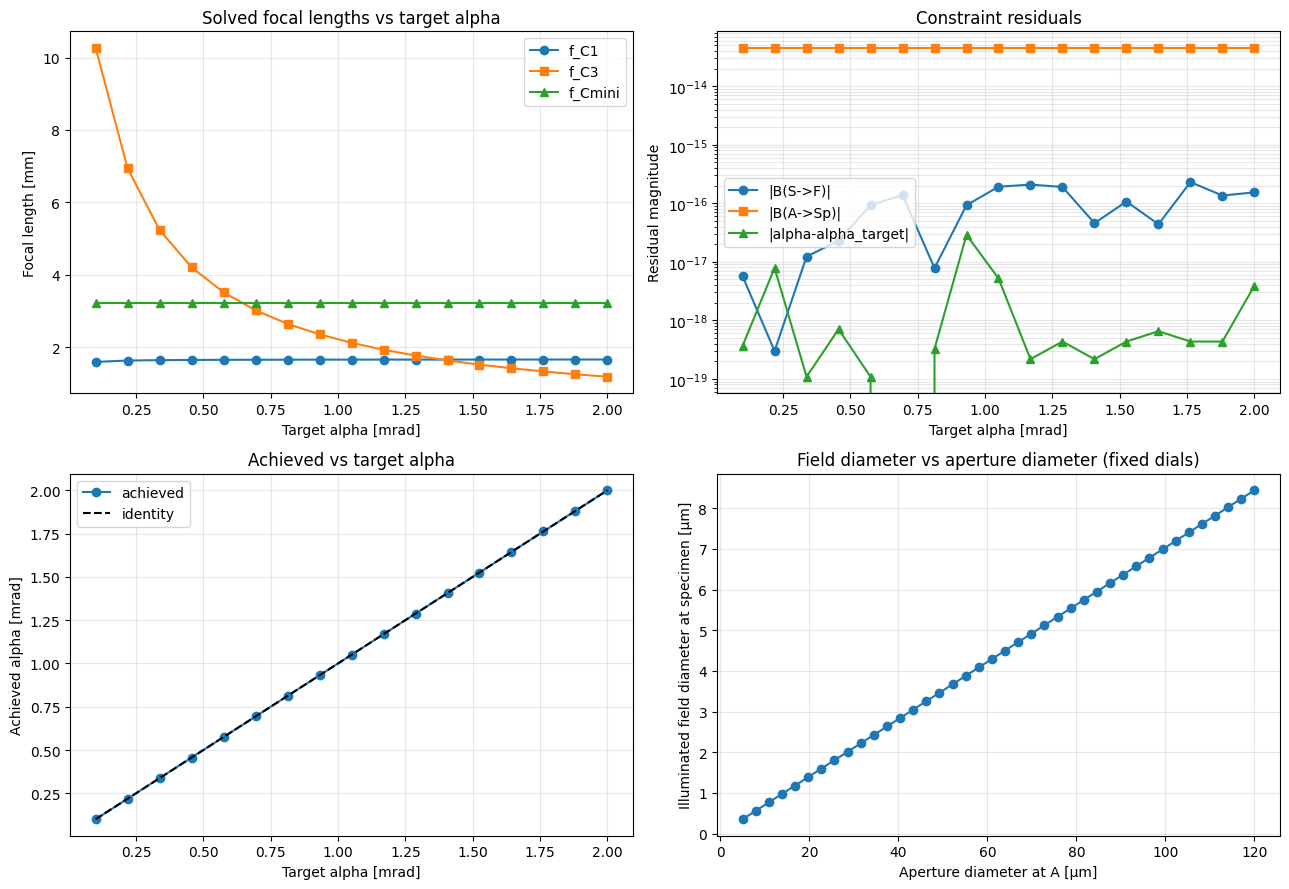

In [41]:
fC1s = np.array([r["f_C1"] for r in sweep_results], dtype=float)
fC3s = np.array([r["f_C3"] for r in sweep_results], dtype=float)
fCms = np.array([r["f_Cmini"] for r in sweep_results], dtype=float)

fig, axs = plt.subplots(2, 2, figsize=(13, 9))

# (1) focal lengths vs alpha target
axs[0, 0].plot(alpha_targets * 1e3, fC1s * 1e3, "o-", label="f_C1")
axs[0, 0].plot(alpha_targets * 1e3, fC3s * 1e3, "s-", label="f_C3")
axs[0, 0].plot(alpha_targets * 1e3, fCms * 1e3, "^-", label="f_Cmini")
axs[0, 0].set_xlabel("Target alpha [mrad]")
axs[0, 0].set_ylabel("Focal length [mm]")
axs[0, 0].set_title("Solved focal lengths vs target alpha")
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

# (2) residual magnitudes (log)
axs[0, 1].plot(alpha_targets * 1e3, res_B_SF, "o-", label="|B(S->F)|")
axs[0, 1].plot(alpha_targets * 1e3, res_B_ASp, "s-", label="|B(A->Sp)|")
axs[0, 1].plot(alpha_targets * 1e3, res_alpha, "^-", label="|alpha-alpha_target|")
axs[0, 1].set_yscale("log")
axs[0, 1].set_xlabel("Target alpha [mrad]")
axs[0, 1].set_ylabel("Residual magnitude")
axs[0, 1].set_title("Constraint residuals")
axs[0, 1].grid(True, which="both", alpha=0.3)
axs[0, 1].legend()

# (3) achieved vs target alpha
axs[1, 0].plot(alpha_targets * 1e3, alpha_achieved * 1e3, "o-", label="achieved")
lims = [float(np.min(alpha_targets) * 1e3), float(np.max(alpha_targets) * 1e3)]
axs[1, 0].plot(lims, lims, "k--", label="identity")
axs[1, 0].set_xlabel("Target alpha [mrad]")
axs[1, 0].set_ylabel("Achieved alpha [mrad]")
axs[1, 0].set_title("Achieved vs target alpha")
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

# (4) field diameter vs aperture diameter (fixed solved dials)
axs[1, 1].plot(aperture_diams * 1e6, field_diams_specimen * 1e6, "o-")
axs[1, 1].set_xlabel("Aperture diameter at A [µm]")
axs[1, 1].set_ylabel("Illuminated field diameter at specimen [µm]")
axs[1, 1].set_title("Field diameter vs aperture diameter (fixed dials)")
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 8.1 Spot-family branch plots (`B_S→F=0`, no `alpha` target)


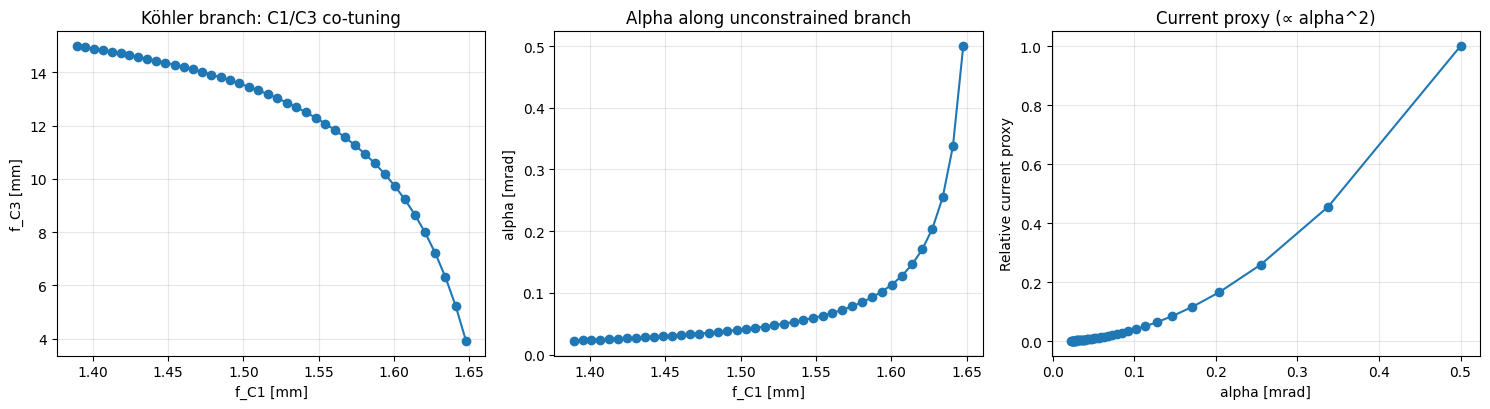

In [42]:
if spot_family_results:
    f1_spot = np.array([p["f_C1"] for p in spot_family_results], dtype=float)
    f3_spot = np.array([p["f_C3"] for p in spot_family_results], dtype=float)
    alpha_spot = np.array([p["alpha"] for p in spot_family_results], dtype=float)
    current_proxy_spot = np.array([p["current_proxy_rel"] for p in spot_family_results], dtype=float)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))

    axs[0].plot(f1_spot * 1e3, f3_spot * 1e3, "o-")
    axs[0].set_xlabel("f_C1 [mm]")
    axs[0].set_ylabel("f_C3 [mm]")
    axs[0].set_title("Köhler branch: C1/C3 co-tuning")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(f1_spot * 1e3, alpha_spot * 1e3, "o-")
    axs[1].set_xlabel("f_C1 [mm]")
    axs[1].set_ylabel("alpha [mrad]")
    axs[1].set_title("Alpha along unconstrained branch")
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(alpha_spot * 1e3, current_proxy_spot, "o-")
    axs[2].set_xlabel("alpha [mrad]")
    axs[2].set_ylabel("Relative current proxy")
    axs[2].set_title("Current proxy (∝ alpha^2)")
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No spot-family plot available for current geometry/bounds.")


### 8.2 Zoom locked-plane plots


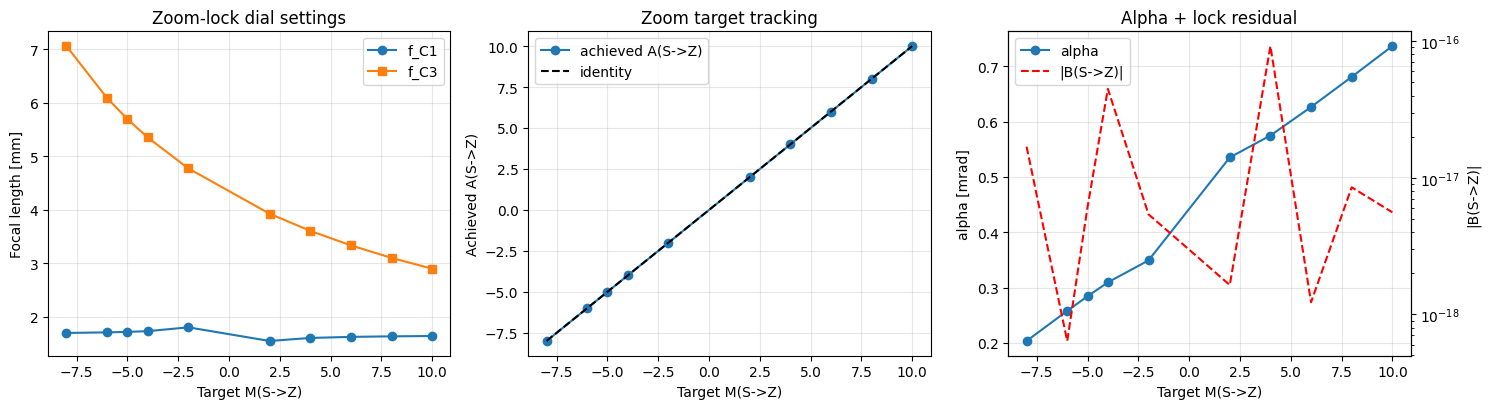

In [43]:
zoom_ok = [r for r in zoom_sweep_results if r["success"]]
if zoom_ok:
    zoom_M_target = np.array([r["M_target"] for r in zoom_ok], dtype=float)
    zoom_A_SZ = np.array([r["A_SZ"] for r in zoom_ok], dtype=float)
    zoom_f1 = np.array([r["f_C1"] for r in zoom_ok], dtype=float)
    zoom_f3 = np.array([r["f_C3"] for r in zoom_ok], dtype=float)
    zoom_alpha = np.array([r["alpha"] for r in zoom_ok], dtype=float)
    zoom_residual = np.array([abs(r["residual_B_SZ"]) for r in zoom_ok], dtype=float)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))

    axs[0].plot(zoom_M_target, zoom_f1 * 1e3, "o-", label="f_C1")
    axs[0].plot(zoom_M_target, zoom_f3 * 1e3, "s-", label="f_C3")
    axs[0].set_xlabel("Target M(S->Z)")
    axs[0].set_ylabel("Focal length [mm]")
    axs[0].set_title("Zoom-lock dial settings")
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    axs[1].plot(zoom_M_target, zoom_A_SZ, "o-", label="achieved A(S->Z)")
    axs[1].plot(zoom_M_target, zoom_M_target, "k--", label="identity")
    axs[1].set_xlabel("Target M(S->Z)")
    axs[1].set_ylabel("Achieved A(S->Z)")
    axs[1].set_title("Zoom target tracking")
    axs[1].grid(True, alpha=0.3)
    axs[1].legend()

    axs[2].plot(zoom_M_target, zoom_alpha * 1e3, "o-", label="alpha")
    axs2 = axs[2].twinx()
    axs2.plot(zoom_M_target, np.maximum(zoom_residual, 1e-20), "r--", label="|B(S->Z)|")
    axs2.set_yscale("log")
    axs[2].set_xlabel("Target M(S->Z)")
    axs[2].set_ylabel("alpha [mrad]")
    axs2.set_ylabel("|B(S->Z)|")
    axs[2].set_title("Alpha + lock residual")
    axs[2].grid(True, alpha=0.3)

    h1, l1 = axs[2].get_legend_handles_labels()
    h2, l2 = axs2.get_legend_handles_labels()
    axs[2].legend(h1 + h2, l1 + l2, loc="best")

    plt.tight_layout()
    plt.show()
else:
    print("No successful zoom-lock points to plot.")


### 8.3 Multistart solution-space plots


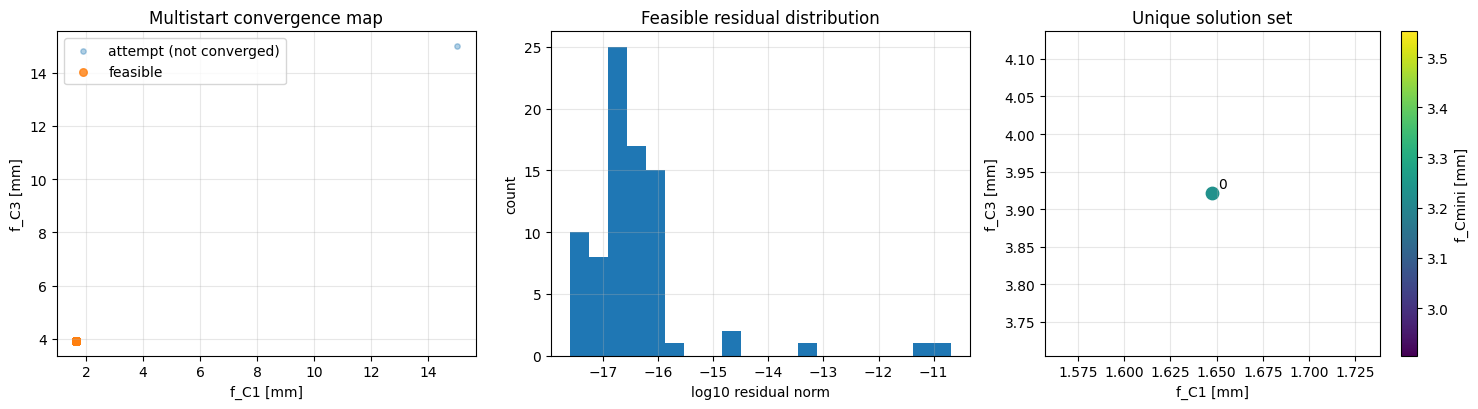

In [44]:
raw_multistart = solution_space.get("raw_results", [])
feasible_multistart = solution_space.get("feasible_results", [])
unique_multistart = solution_space.get("unique_solutions", [])

if raw_multistart:
    raw_f1 = np.array([s["f_C1"] for s in raw_multistart], dtype=float)
    raw_f3 = np.array([s["f_C3"] for s in raw_multistart], dtype=float)
    raw_ok = np.array([bool(s["success"]) for s in raw_multistart], dtype=bool)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))

    axs[0].scatter(raw_f1[~raw_ok] * 1e3, raw_f3[~raw_ok] * 1e3, s=15, alpha=0.35, label="attempt (not converged)")
    if np.any(raw_ok):
        axs[0].scatter(raw_f1[raw_ok] * 1e3, raw_f3[raw_ok] * 1e3, s=30, alpha=0.8, label="feasible")
    axs[0].set_xlabel("f_C1 [mm]")
    axs[0].set_ylabel("f_C3 [mm]")
    axs[0].set_title("Multistart convergence map")
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc="best")

    if feasible_multistart:
        f_norm = np.array([s["residual_norm"] for s in feasible_multistart], dtype=float)
        axs[1].hist(np.log10(np.maximum(f_norm, 1e-20)), bins=20)
        axs[1].set_xlabel("log10 residual norm")
        axs[1].set_ylabel("count")
        axs[1].set_title("Feasible residual distribution")
        axs[1].grid(True, alpha=0.3)
    else:
        axs[1].text(0.5, 0.5, "No feasible points", ha="center", va="center")
        axs[1].set_axis_off()

    if unique_multistart:
        u_f1 = np.array([s["f_C1"] for s in unique_multistart], dtype=float)
        u_f3 = np.array([s["f_C3"] for s in unique_multistart], dtype=float)
        u_fm = np.array([s["f_Cmini"] for s in unique_multistart], dtype=float)
        sc = axs[2].scatter(u_f1 * 1e3, u_f3 * 1e3, c=u_fm * 1e3, s=80, cmap="viridis")
        for i, s in enumerate(unique_multistart):
            axs[2].annotate(str(i), (s["f_C1"] * 1e3, s["f_C3"] * 1e3), textcoords="offset points", xytext=(4, 4))
        axs[2].set_xlabel("f_C1 [mm]")
        axs[2].set_ylabel("f_C3 [mm]")
        axs[2].set_title("Unique solution set")
        axs[2].grid(True, alpha=0.3)
        cbar = plt.colorbar(sc, ax=axs[2])
        cbar.set_label("f_Cmini [mm]")
    else:
        axs[2].text(0.5, 0.5, "No unique solutions", ha="center", va="center")
        axs[2].set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("No multistart results available to plot.")


In [45]:
print("Acceptance checks summary")
print("-------------------------")
print("Default target success:", default_result["success"])
print("Default alpha target [mrad]:", cfg["alpha_target"] * 1e3)
print("Default alpha achieved [mrad]:", default_result["alpha"] * 1e3)
print("Default |B_S->F|:", abs(default_result["residual_B_SF"]))
print("Default |B_A->Sp|:", abs(default_result["B_ASp"]))
print("Sweep solved count:", n_ok, "/", len(sweep_results))

if "spot_family_results" in globals():
    print("Spot-family points:", len(spot_family_results))
    if spot_family_results:
        alpha_spot_vals = np.array([p["alpha"] for p in spot_family_results], dtype=float)
        print("Spot-family alpha range [mrad]:", float(np.min(alpha_spot_vals) * 1e3), "to", float(np.max(alpha_spot_vals) * 1e3))

print("Zoom sweep solved count:", n_zoom_ok, "/", len(zoom_sweep_results))
if zoom_sweep_results:
    zoom_ok_vals = [r for r in zoom_sweep_results if r["success"]]
    if zoom_ok_vals:
        zoom_M_vals = np.array([r["M_target"] for r in zoom_ok_vals], dtype=float)
        print("Zoom M target range:", float(np.min(zoom_M_vals)), "to", float(np.max(zoom_M_vals)))

print("Multistart unique solutions:", len(solution_space.get("unique_solutions", [])))
print("Multistart feasible solves:", len(solution_space.get("feasible_results", [])), "/", len(solution_space.get("raw_results", [])))


Acceptance checks summary
-------------------------
Default target success: True
Default alpha target [mrad]: 0.5
Default alpha achieved [mrad]: 0.5
Default |B_S->F|: 5.0474060115352874e-17
Default |B_A->Sp|: 4.5402368559980175e-14
Sweep solved count: 17 / 17
Spot-family points: 42
Spot-family alpha range [mrad]: 0.022290027508602303 to 0.5
Zoom sweep solved count: 10 / 10
Zoom M target range: -8.0 to 10.0
Multistart unique solutions: 1
Multistart feasible solves: 81 / 82
